In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plotter
import seaborn as sns

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\lenta_ru_news_2019_2023.csv")

In [3]:
df.head(5)

,url,title,text,topic,tags,date
0,https://lenta.ru/news/2019/12/15/prsm/,Россиянам дали советы по выбору чая,Россиянам дали советы при выборе чая. Рекоменд...,Россия,Общество,2019-12-15
1,https://lenta.ru/news/2019/12/15/fb/,В Госдуме назвали японское заявление о Курилах...,Спикер Госдумы Вячеслав Володин назвал угрозой...,Россия,Политика,2019-12-15
2,https://lenta.ru/news/2019/12/15/kino/,Украинская ЛГБТ-активистка обвинила ню-фотогра...,Украинская ЛГБТ-активистка Виктория Гуйвик обв...,Культура,Фотография,2019-12-15
3,https://lenta.ru/news/2019/12/15/alba/,Полицейские застрелили порезавшего мать буйног...,В Москве полицейские застрелили мужчину при по...,Силовые структуры,Криминал,2019-12-15
4,https://lenta.ru/news/2019/12/15/anons/,Беглого президента Боливии решили арестовать,Исполняющая обязанности президента Боливии Жан...,Мир,Политика,2019-12-15


In [4]:
lenta_topics = {
    "Россия": 0,
    "Экономика": 1,
    "Силовые структуры": 2,
    "Бывший СССР": 3,
    "Спорт": 4,
    "Забота о себе": 5,
    "Здоровье": 5,
    "Строительство": 6,
    "Путешествия": 7,
    "Наука и техника": 8,
    "Интернет и СМИ": 0,
    "Бизнес": 1,
    }

In [5]:
df["number"] = df["topic"].apply(lambda x: lenta_topics[x] if x in lenta_topics else None)
df = df.dropna(subset=['number'])
df = df.dropna(subset=['text'])

df["number"] = df["number"].apply(lambda x: int(x))

In [6]:
df['number'].value_counts()

number
0    118456
3     51071
1     49015
2     30249
4     28442
8     25209
7     19308
5      7589
Name: count, dtype: int64

In [11]:
train_df, test_df = train_test_split(df, random_state=13)

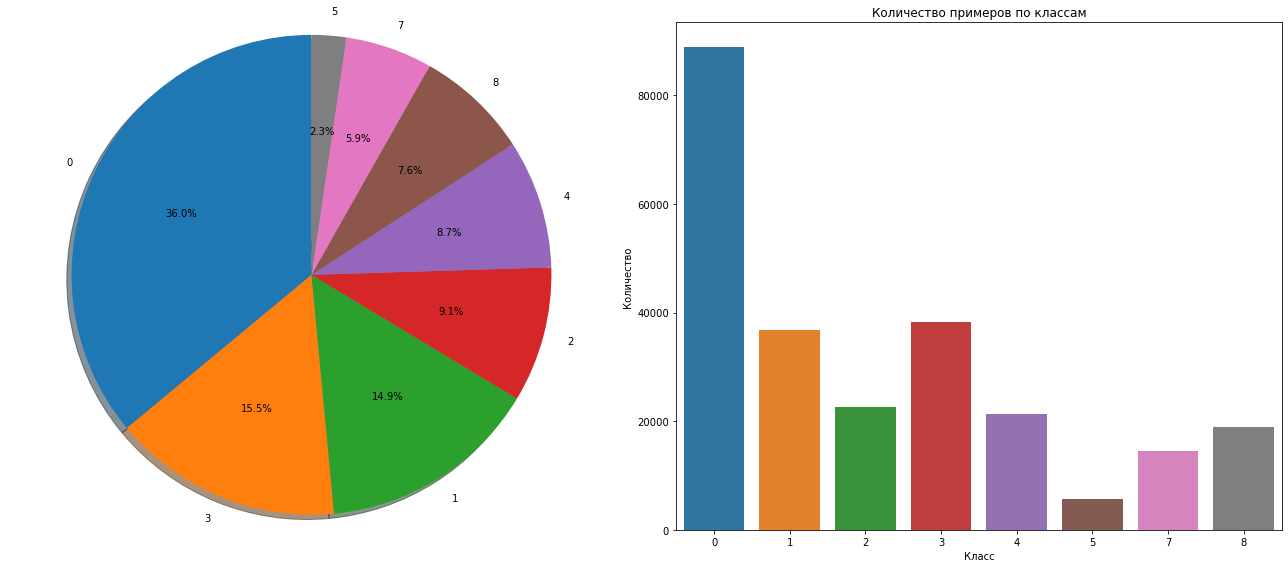

In [18]:
# Считаем, сколько примеров каждого класса
counts = train_df['number'].value_counts()
labels = counts.index.astype(str)    # метки классов
sizes = counts.values                # размеры секторов

# Делаем explode: небольшое смещение только для самого частого класса
explode = [0.1 if cls == counts.idxmax() else 0 for cls in labels]

# Рисуем
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1) Круговая диаграмма
axes[0].pie(
    sizes,
    labels=labels,
    explode=explode,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)

axes[0].axis('equal')  # чтобы круг не искажался

# 2) Countplot через seaborn
sns.countplot(x='number', data=train_df, ax=axes[1])
axes[1].set_title('Количество примеров по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

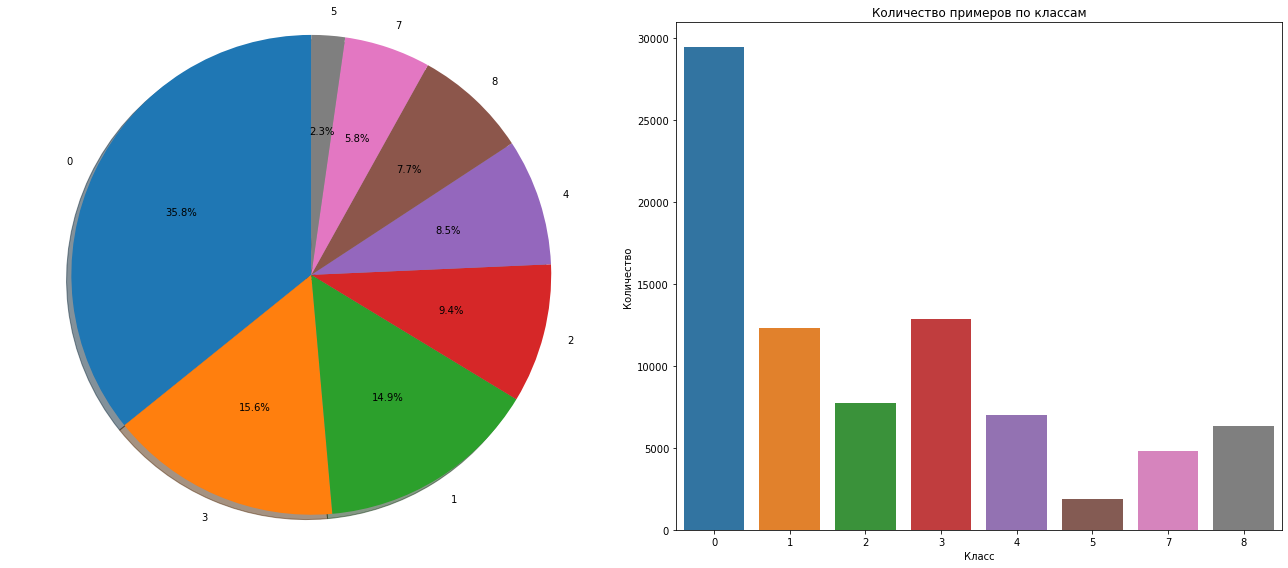

In [20]:
# Считаем, сколько примеров каждого класса
counts = test_df['number'].value_counts()
labels = counts.index.astype(str)    # метки классов
sizes = counts.values                # размеры секторов

# Делаем explode: небольшое смещение только для самого частого класса
explode = [0.1 if cls == counts.idxmax() else 0 for cls in labels]

# Рисуем
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1) Круговая диаграмма
axes[0].pie(
    sizes,
    labels=labels,
    explode=explode,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)

axes[0].axis('equal')  # чтобы круг не искажался

# 2) Countplot через seaborn
sns.countplot(x='number', data=test_df, ax=axes[1])
axes[1].set_title('Количество примеров по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

# CountVectorizer Train 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
x_train, x_test, y_train, y_test = train_test_split(df.text, df.number, random_state=13)

## LogisticRegression

In [9]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90     29468
           1       0.93      0.92      0.92     12283
           2       0.93      0.91      0.92      7726
           3       0.90      0.89      0.90     12852
           4       0.99      0.99      0.99      7030
           5       0.93      0.87      0.90      1861
           7       0.96      0.92      0.94      4788
           8       0.95      0.91      0.93      6327

    accuracy                           0.92     82335
   macro avg       0.93      0.92      0.92     82335
weighted avg       0.92      0.92      0.92     82335



## KNeighborsClassifier

In [15]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = KNeighborsClassifier()
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.41      0.95      0.57     29468
           1       0.73      0.18      0.28     12283
           2       0.91      0.17      0.28      7726
           3       0.55      0.27      0.36     12852
           4       0.99      0.28      0.43      7030
           5       1.00      0.00      0.01      1861
           7       0.97      0.07      0.12      4788
           8       0.98      0.04      0.07      6327

    accuracy                           0.45     82335
   macro avg       0.82      0.24      0.27     82335
weighted avg       0.66      0.45      0.38     82335



# TF-IDF

In [8]:
with open("russian.txt", "r", encoding="utf-8") as file:
    stop_words = [line.strip() for line in file]

## LogisticRegression

In [13]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92     29468
           1       0.93      0.93      0.93     12283
           2       0.94      0.91      0.92      7726
           3       0.92      0.92      0.92     12852
           4       0.99      0.98      0.99      7030
           5       0.93      0.91      0.92      1861
           7       0.97      0.93      0.95      4788
           8       0.96      0.92      0.94      6327

    accuracy                           0.93     82335
   macro avg       0.94      0.93      0.94     82335
weighted avg       0.93      0.93      0.93     82335



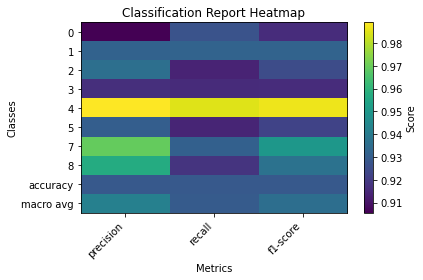

              precision    recall  f1-score       support
0              0.905547  0.926904  0.916101  29468.000000
1              0.931803  0.932183  0.931993  12283.000000
2              0.935976  0.913927  0.924820   7726.000000
3              0.916667  0.915811  0.916239  12852.000000
4              0.989002  0.984922  0.986957   7030.000000
5              0.930525  0.914025  0.922201   1861.000000
7              0.969137  0.931287  0.949835   4788.000000
8              0.956837  0.917971  0.937001   6327.000000
accuracy       0.928973  0.928973  0.928973      0.928973
macro avg      0.941937  0.929628  0.935643  82335.000000
weighted avg   0.929384  0.928973  0.929067  82335.000000


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Получаем отчёт в виде словаря
report_dict = classification_report(y_test, tf_pred, output_dict=True)

# 2. Преобразуем в DataFrame и транспонируем
report_df = pd.DataFrame(report_dict).transpose()

# 3. Выбираем метрики и классы (исключая строку support)
metrics = ['precision', 'recall', 'f1-score']
classes = report_df.index[:-1]

# 4. Подготавливаем данные для тепловой карты
heatmap_data = report_df.loc[classes, metrics].values

# 5. Рисуем тепловую карту
fig, ax = plt.subplots()
im = ax.imshow(heatmap_data, aspect='auto')

# Настраиваем подписи осей
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes)

# Добавляем цветовую шкалу и заголовки
plt.colorbar(im, ax=ax, label='Score')
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.tight_layout()
plt.show()

# (Опционально) вывести сам DataFrame для удобства
print(report_df)

## KNeighborsClassifier

In [10]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = KNeighborsClassifier()
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.63      0.43      0.51     29468
           1       0.90      0.28      0.42     12283
           2       0.89      0.21      0.34      7726
           3       0.90      0.24      0.38     12852
           4       0.99      0.48      0.65      7030
           5       0.96      0.05      0.10      1861
           7       0.92      0.34      0.49      4788
           8       0.13      0.96      0.22      6327

    accuracy                           0.39     82335
   macro avg       0.79      0.37      0.39     82335
weighted avg       0.75      0.39      0.44     82335



# Обработка

In [10]:
import string
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

In [11]:
with open("russian.txt", "r", encoding="utf-8") as file:
    stop_words = [line.strip() for line in file]

In [12]:
punctuations = string.punctuation

In [13]:
def remove_stopwords(text: str, words_to_remove: list) -> str:
   
    words = text.split()
    
    filtered_words = [
        word for word in words 
        if word.lower() not in {w.lower() for w in words_to_remove}
    ]
    
    return " ".join(filtered_words)

def remove_chars_simple(text: str, chars: list) -> str:
    return ''.join([char for char in text if char not in chars])

def tokenize_words(text: str) -> list:
    g = word_tokenize(text)
    f = ""
    for i in g:
        f = f + " " +i
    return f[1:]

In [14]:
def process_text(text: str) -> str:
    processed = text.lower() 
    processed = remove_stopwords(processed, stop_words)
    processed = remove_chars_simple(processed, punctuations)
    processed = tokenize_words(processed)
    processed = " ".join(processed.split()) 
    return processed

In [30]:
#halfed_df = df.iloc[::2].reset_index(drop=True)

In [31]:
#halfed_df['tokenized_Text'] = halfed_df['text'].apply(process_text)

In [32]:
#halfed_df.to_csv('C:\\Users\\User\\Desktop\\halfed_df.csv', index=False, encoding='utf-8')

In [31]:
halfed_df = pd.read_csv('C:\\Users\\User\\Desktop\\halfed_df.csv')

In [15]:
#quartered_df = halfed_df.iloc[::2].reset_index(drop=True)

In [15]:
#quartered_df['tokenized_Text'] = quartered_df['text'].apply(process_text)
quartered_df = pd.read_csv("C:\\Users\\User\\Desktop\\quartered_df.csv")

In [16]:
quartered_df.head(5)

,url,title,text,topic,tags,date,number,tokenized_Text
0,https://lenta.ru/news/2019/12/15/prsm/,Россиянам дали советы по выбору чая,Россиянам дали советы при выборе чая. Рекоменд...,Россия,Общество,2019-12-15,0,россиянам дали советы выборе чая рекомендации ...
1,https://lenta.ru/news/2019/12/15/tattoo/,Россиян предостерегли от нового способа кражи ...,Россиян предостерегли от нового способа кражи ...,Россия,Общество,2019-12-15,0,россиян предостерегли нового способа кражи пер...
2,https://lenta.ru/news/2019/12/15/cluchaynost/,«Тоттенхэм» прервал 11-матчевую беспроигрышную...,«Тоттенхэм» на выезде обыграл «Вулверхэмптоном...,Спорт,NaN,2019-12-15,4,« тоттенхэм » выезде обыграл « вулверхэмптоном...
3,https://lenta.ru/news/2019/12/15/potom/,Аномальные облака над Сибирью попали на фото и...,Россиянка сфотографировала аномальные облака н...,Путешествия,Мир,2019-12-15,7,россиянка сфотографировала аномальные облака г...
4,https://lenta.ru/news/2019/12/15/peremirie/,Названы лучшие гаджеты уходящего десятилетия,"Журнал Time назвал десять лучших, по мнению ре...",Наука и техника,Гаджеты,2019-12-15,8,журнал time назвал лучших мнению редакции гадж...


# quartered_df

# CountVectorizer Train 

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
x_train, x_test, y_train, y_test = train_test_split(quartered_df.tokenized_Text, quartered_df.number, random_state=13)

## LogisticRegression

In [25]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      7423
           1       0.92      0.89      0.91      3119
           2       0.91      0.88      0.89      1900
           3       0.88      0.89      0.88      3137
           4       0.98      0.97      0.98      1785
           5       0.88      0.83      0.86       449
           7       0.96      0.87      0.91      1196
           8       0.95      0.90      0.92      1575

    accuracy                           0.90     20584
   macro avg       0.92      0.89      0.90     20584
weighted avg       0.90      0.90      0.90     20584



## KNeighborsClassifier

In [26]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = KNeighborsClassifier()
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.37      0.96      0.54      7423
           1       1.00      0.00      0.00      3119
           2       0.84      0.02      0.04      1900
           3       0.59      0.22      0.32      3137
           4       0.98      0.06      0.12      1785
           5       0.00      0.00      0.00       449
           7       0.93      0.01      0.02      1196
           8       1.00      0.01      0.01      1575

    accuracy                           0.39     20584
   macro avg       0.71      0.16      0.13     20584
weighted avg       0.67      0.39      0.26     20584



C:\Users\User\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [28]:
#пробуем биграммы и weights='distance'
vec = CountVectorizer(ngram_range=(1, 2))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = KNeighborsClassifier(metric='cosine')
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      7423
           1       0.91      0.78      0.84      3119
           2       0.80      0.87      0.83      1900
           3       0.82      0.83      0.82      3137
           4       0.95      0.97      0.96      1785
           5       0.86      0.76      0.81       449
           7       0.93      0.77      0.84      1196
           8       0.94      0.83      0.88      1575

    accuracy                           0.85     20584
   macro avg       0.88      0.83      0.85     20584
weighted avg       0.85      0.85      0.85     20584



# TF-IDF 

## LogisticRegression

In [28]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      7423
           1       0.92      0.91      0.92      3119
           2       0.92      0.90      0.91      1900
           3       0.89      0.90      0.89      3137
           4       0.98      0.98      0.98      1785
           5       0.88      0.87      0.88       449
           7       0.96      0.88      0.92      1196
           8       0.95      0.91      0.93      1575

    accuracy                           0.91     20584
   macro avg       0.92      0.91      0.92     20584
weighted avg       0.91      0.91      0.91     20584



## KNeighborsClassifier

In [22]:
#пробуем metric='cosine'
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = KNeighborsClassifier(metric='cosine')
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      7423
           1       0.89      0.81      0.85      3119
           2       0.82      0.85      0.83      1900
           3       0.81      0.84      0.83      3137
           4       0.96      0.96      0.96      1785
           5       0.84      0.82      0.83       449
           7       0.87      0.79      0.83      1196
           8       0.90      0.88      0.89      1575

    accuracy                           0.85     20584
   macro avg       0.86      0.85      0.86     20584
weighted avg       0.85      0.85      0.85     20584



# Halfed_df

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
x_train, x_test, y_train, y_test = train_test_split(halfed_df.tokenized_Text, halfed_df.number, random_state=13)

# CountVectorizer Train 

## LogisticRegression

In [33]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     14779
           1       0.92      0.90      0.91      6259
           2       0.91      0.89      0.90      3753
           3       0.89      0.90      0.90      6379
           4       0.99      0.98      0.99      3544
           5       0.90      0.87      0.88       928
           7       0.95      0.91      0.93      2399
           8       0.95      0.89      0.92      3127

    accuracy                           0.91     41168
   macro avg       0.92      0.91      0.92     41168
weighted avg       0.91      0.91      0.91     41168



## KNeighborsClassifier

In [34]:
vec = CountVectorizer(ngram_range=(1, 1))

bow = vec.fit_transform(x_train)
bow_test = vec.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

clf = KNeighborsClassifier(metric='cosine')
clf.fit(bow, y_train)
pred = clf.predict(bow_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.75      0.86      0.80     14779
           1       0.89      0.77      0.83      6259
           2       0.79      0.83      0.81      3753
           3       0.78      0.77      0.78      6379
           4       0.95      0.95      0.95      3544
           5       0.86      0.63      0.73       928
           7       0.92      0.76      0.83      2399
           8       0.95      0.74      0.83      3127

    accuracy                           0.82     41168
   macro avg       0.86      0.79      0.82     41168
weighted avg       0.83      0.82      0.82     41168



# TF-IDF

## LogisticRegression

In [35]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90     14779
           1       0.92      0.92      0.92      6259
           2       0.92      0.90      0.91      3753
           3       0.90      0.91      0.91      6379
           4       0.99      0.98      0.99      3544
           5       0.89      0.89      0.89       928
           7       0.96      0.92      0.94      2399
           8       0.95      0.90      0.92      3127

    accuracy                           0.92     41168
   macro avg       0.93      0.92      0.92     41168
weighted avg       0.92      0.92      0.92     41168



## KNeighborsClassifier

In [36]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1, 3), stop_words=stop_words)

bow = tfidf.fit_transform(x_train)
bow_test = tfidf.transform(x_test)

scaler = MaxAbsScaler()
bow = scaler.fit_transform(bow)
bow_test = scaler.transform(bow_test)

model = KNeighborsClassifier(metric='cosine')
model.fit(bow, y_train)
tf_pred = model.predict(bow_test)

print(classification_report(y_test, tf_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85     14779
           1       0.90      0.84      0.87      6259
           2       0.84      0.85      0.84      3753
           3       0.84      0.84      0.84      6379
           4       0.97      0.96      0.96      3544
           5       0.86      0.84      0.85       928
           7       0.92      0.80      0.86      2399
           8       0.92      0.85      0.89      3127

    accuracy                           0.86     41168
   macro avg       0.88      0.86      0.87     41168
weighted avg       0.86      0.86      0.86     41168

